In [268]:
from typing import Tuple, List, Union, Optional
import torch
import torch.nn as nn
import numpy as np
from torch import Tensor
from numpy import ndarray
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import OrderedDict, defaultdict
from scipy.spatial import ConvexHull, HalfspaceIntersection
from time import time
from torch.optim import Adam

import sys
sys.path.append('../src/')
from auto_LiRPA import BoundedModule, BoundedTensor
from auto_LiRPA.perturbations import PerturbationLpNorm

In [269]:
to_numpy = lambda x : x.detach().cpu().numpy()
set_t = {
    'dtype': torch.float32,
    'device': torch.device('cuda')
}

In [270]:
class ConvexPolytope(nn.Module):
    """
    This object takes the planes of a convex polytope and returns exactly 0 along every neuron at the final layer if the point is inside
    the object, otherwise the point is outside the object.
    """
    def __init__(self, A: Tensor, b: Tensor, use_sum_layer: bool = False, translation: Optional[Tensor] = None,
                 normalize: bool = True):
        """
        Initialization method. Note that it may be better to let 'use_sum_layer' be False for convex polytope intersection tests as this will
        allow CROWN more flexibility to perform clipping.
        :param A:               Plane coefficients.
        :param b:               Plane offsets.
        :param use_sum_layer:   If true, the output is the sum of the final layer.
        :param translation:     If given, the input will be translated before being passed to the model.
        :param normalize:       If true, normalizes the hyperplanes.
        """
        super().__init__()
        A = A.clone().detach()
        b = b.clone().detach()
        translation = translation.clone().detach() if translation is not None else None
        if normalize:
            norms = torch.norm(A, dim=1, keepdim=True)
            A /= norms
            b /= norms.squeeze(1)
        out_features, in_features = A.shape[0], A.shape[1]
        self.hyperplane_layer = nn.Linear(in_features, out_features, bias=True)
        self._use_sum_layer = use_sum_layer
        self._in_features = in_features
        self._out_features = 1 if use_sum_layer else out_features
        with torch.no_grad():  # Disable gradient tracking for manual initialization
            self.hyperplane_layer.weight.copy_(A.cpu())
            self.hyperplane_layer.bias.copy_(b.cpu())

        layers = []  # holds all model layers
        # translates the input if desired
        self.translation_layer = nn.Linear(in_features, in_features, bias=True)
        with torch.no_grad():
            self.translation_layer.weight.copy_(torch.eye(in_features))
            if translation is not None:
                self.translation_layer.bias.copy_(translation.cpu())
            else:
                self.translation_layer.bias.fill_(0.)
        layers.append(self.translation_layer)

        # append hyperplanes and ReLU layers
        layers.extend([self.hyperplane_layer, nn.ReLU()])

        if use_sum_layer:
            # if desired, collapses the output to a single value that is only 0 if
            # the point is inside the convex polytope formed by the planes
            sum_layer = nn.Linear(out_features, 1, bias=False)
            with torch.no_grad():
                sum_layer.weight.copy_(torch.ones_like(sum_layer.weight))
            layers.append(sum_layer)
        else:
            identity_layer = nn.Linear(out_features, out_features, bias=False)
            with torch.no_grad():
                identity_layer.weight.copy_(torch.eye(out_features))
            layers.append(identity_layer)

        self.model = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        return self.model(x)

    def hyperplane_output(self, x: Tensor) -> Tensor:
        return self.hyperplane_output(x)

    def get_lower_bounds(self, x: Tensor, eps: Tensor) -> Tensor:
        pass

    @property
    def device(self):
        return next(self.model.parameters()).device

    @property
    def dtype(self):
        return next(self.model.parameters()).dtype

    @property
    def in_features(self):
        return self._in_features

    @property
    def out_features(self):
        return self._out_features

    @property
    def uses_sum_layer(self):
        return self._use_sum_layer

class MultiConvexPolytopes(nn.Module):
    """
    This class takes multiple convex polytopes and at the final layer, concatenates all of their outputs. If every neuron at the final
    layer is 0, then every polytope intersects one another.
    """
    def __init__(self, polytopes: Union[Tuple[ConvexPolytope], List[ConvexPolytope]]):
        super().__init__()
        self._num_polytopes = len(polytopes)
        self._polytope_indices = []
        start = 0
        for i, polytope in enumerate(polytopes):
            # appends the indices of the output that will correspond to the outputs of this polytope
            self._polytope_indices.append(torch.arange(start, start + polytope.out_features, dtype=torch.int))
            start += polytope.out_features
        self.polytopes = nn.ModuleList(polytopes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        outputs = [polytope(x) for polytope in self.polytopes]  # Forward pass for each polytope
        return torch.cat(outputs, dim=-1)  # Concatenate along the last dimension

    def polytope_mask(self, p_idx: int) -> Tensor:
        """
        If the outputs of a certain polytope are desired, run a forward pass and use this method
        to produce a mask that can help retrieve the polytope's outputs.
        :param p_idx:
        :return:
        """
        return self._polytope_indices[p_idx]

    @property
    def device(self):
        return next(self.parameters()).device

    @property
    def dtype(self):
        return next(self.parameters()).dtype

    @property
    def num_polytopes(self):
        return self._num_polytopes

In [271]:
def plot_2d_domain(x_L: Tensor, x_U: Tensor, lA: Tensor, lbias: Tensor, thresholds: Tensor,
                   new_x_L: Optional[Tensor] = None, new_x_U: Optional[Tensor] = None,
                   net: Optional[Union[MultiConvexPolytopes, ConvexPolytope]] = None, grid_samples: int = 1000,
                   plot_args: Optional[dict] = None):
  batches, spec_dim, input_dim = lA.shape
  default_plot_args = {
      'subplot_max_width': 2,
      'show_grid': True,
      'show_ticks': True,
      'show_legend': True,
      'show_labels': True,
      'global_x_L': None,
      'global_x_U': None,
      'plot_intersection': False,
      'subplot_titles': None,
      'figsize': (8,8)
  }
  if plot_args is not None:
    default_plot_args.update(plot_args)
  plot_args = default_plot_args
  subplot_max_width = plot_args.get('subplot_max_width')
  global_x_L = plot_args.get('global_x_L')
  global_x_U = plot_args.get('global_x_U')
  show_grid = plot_args.get('show_grid')
  show_labels = plot_args.get('show_labels')
  show_legend = plot_args.get('show_legend')
  show_ticks = plot_args.get('show_ticks')
  plot_intersection = plot_args.get('plot_intersection')
  figsize = plot_args.get('figsize')
  subplot_titles = plot_args.get('subplot_titles')
  assert subplot_titles is None or len(subplot_titles) == batches, "Number of subplot titles must match number of batches"
  plot_new_input = new_x_L is not None and new_x_U is not None
  use_global_x_L = global_x_L is not None
  use_global_x_U = global_x_U is not None
  num_rows = int(batches / subplot_max_width) + 1
  num_cols = min(batches, subplot_max_width)

  fig = plt.figure(figsize=figsize)
  # Create a mesh grid over the input domain
  all_x_L_np = to_numpy(x_L.flatten(1))
  all_x_U_np = to_numpy(x_U.flatten(1))
  if plot_new_input:
    all_new_x_L_np = to_numpy(new_x_L.flatten(1))
    all_new_x_U_np = to_numpy(new_x_U.flatten(1))
  all_lA_np = to_numpy(lA).reshape(batches, spec_dim, input_dim)
  all_lbias_np = to_numpy(lbias.flatten(1))
  all_thresholds_np = to_numpy(thresholds.flatten(1))
  max_z = -np.inf
  for b in range(batches):
    # get current batch parameters
    x_L_np = all_x_L_np[b]
    x_U_np = all_x_U_np[b]
    if plot_new_input:
      new_x_L_np = all_new_x_L_np[b]
      new_x_U_np = all_new_x_U_np[b]
    global_x_L = global_x_L if use_global_x_L else x_L_np
    global_x_U = global_x_U if use_global_x_U else x_U_np
    lA_np = all_lA_np[b]
    lbias_np = all_lbias_np[b]
    thresholds_np = all_thresholds_np[b]

    # randomly sample the input space
    x = np.linspace(global_x_L[0], global_x_U[0], 1000)
    y = np.linspace(global_x_L[1], global_x_U[1], 1000)
    X, Y = np.meshgrid(x, y)
    if plot_intersection:
      inter_pt = np.linalg.lstsq(lA_np, -lbias_np, rcond=None)[0]

    subplot_idx = (num_rows, num_cols, b+1)
    ax = plt.subplot(*subplot_idx)
    rect_input = patches.Rectangle(x_L_np.tolist(), *(x_U_np - x_L_np).tolist(), linewidth=1, edgecolor='black', facecolor='none', label="Original Input Domain")
    ax.add_patch(rect_input)
    if plot_new_input:
      rect_new_input = patches.Rectangle(new_x_L_np.tolist(), *(new_x_U_np - new_x_L_np).tolist(), linewidth=1, edgecolor='r', facecolor='none', label="Clipped Input Domain")
      ax.add_patch(rect_new_input)

    # Plot each convex bound
    for i in range(len(lA_np)):
        a, k = lA_np[i]
        c = lbias_np[i]
        d = thresholds_np[i]
        Z = a*X + k*Y + c
        max_z = max(max_z, np.max(Z))
        label = f'$x\u0332 \geq a^\\top_{i+1}x̂ - |a^\\top_{i+1}|\epsilon + lbias_{i+1}$'
        ax.contour(X, Y, Z, levels=[d], linewidths=1, colors='k')
        ax.contourf(X, Y, Z, levels=[d, max_z], alpha=0.3)
        # Avoid dividing by zero for vertical lines
        # if k != 0:
        #     y_vals = (d - a * x - c) / k
        #     plt.plot(x, y_vals, label=label)
        # else:
        #     x_val = (k - c) / a
        #     plt.axvline(x_val, label=label)
    if plot_intersection:
      ax.scatter(inter_pt[0], inter_pt[1], color='red', label='Intersection Point')

    if net is not None:
        # if the net object is not None, we assume we want to sample the input space
        # and plot the result of the points
        x = np.linspace(x_L_np[0], x_U_np[0], grid_samples)
        y = np.linspace(x_L_np[1], x_U_np[1], grid_samples)
        X, Y = np.meshgrid(x, y)
        samples_np = np.stack((X.flatten(), Y.flatten()), axis=1)
        samples = torch.from_numpy(samples_np).to(device=net.device, dtype=net.dtype)
        Z_torch = net(samples)
        if isinstance(net, ConvexPolytope):
            if net.out_features == 1:
                Z_torch = Z_torch.squeeze(1)
            else:
                Z_torch = (Z_torch > 0).any(1).to(dtype=net.dtype)
            Z = to_numpy(Z_torch)
            outside_mask = (Z > 0)
            inside_mask = np.logical_not(outside_mask)
        elif isinstance(net, MultiConvexPolytopes):
            outside_mask = torch.zeros((samples.shape[0], net.num_polytopes))
            for i in range(net.num_polytopes):
                p_mask = net.polytope_mask(i)
                p_outputs = Z_torch[:, p_mask]
                outside_mask[:, i] = (p_outputs > 0).any(1).to(dtype=net.dtype)
            outside_mask = to_numpy(outside_mask.all(1))
            inside_mask = np.logical_not(outside_mask)
        else:
            raise ValueError("net is not a ConvexPolytope or MultiConvexPolytopes")

        inside_samples = samples_np[inside_mask]
        outside_samples = samples_np[outside_mask]
        ax.scatter(inside_samples[:, 0], inside_samples[:, 1], color='green', label='Inside Points', s=10)
        ax.scatter(outside_samples[:, 0], outside_samples[:, 1], color='red', label='Outside Points', s=10)

    if show_labels:
      ax.set_title('Input Domain with Constraints')
      ax.set_xlabel('$x_1$')
      ax.set_ylabel('$x_2$')
    ax.set_xlim(global_x_L[0], global_x_U[0])
    ax.set_ylim(global_x_L[1], global_x_U[1])
    if not show_ticks:
      ax.axis('off')
    if show_grid: ax.grid()
    if show_legend: ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    if subplot_titles is not None:
      ax.set_title(subplot_titles[b])
  return ax

def plot_convex_polytope(ax, A: ndarray, b: ndarray, translation: Optional[ndarray],
                         color: str = 'cyan', label: Optional[str] = None):
    """
    Plots a convex polytope defined by hyperplanes Ax + b ≤ 0.
    :param ax:      Axes object to plot on.
    :param A:       (N, 2) matrix where each row is a normal vector of a hyperplane.
    :param b:       (N,) vector of biases.
    :param color:   Color to use for filling in the polytope.
    :param label:   Label to give the polytope.
    :return:
    """
    # Convert Ax + b ≤ 0 to half-space format
    halfspaces = np.hstack([A, b.reshape(-1, 1)])  # Each row is [a1, a2, b]

    # Find a feasible starting point (e.g., the centroid of some bounded region)
    feasible_point = np.linalg.lstsq(A, -b, rcond=None)[0]

    # The feasible point must be strictly and 'clearly' inside
    eps = 1e-1
    ptbs = [(eps, eps), (eps, -eps), (-eps, eps), (-eps, -eps)]
    ptbs_np = [np.array(ptb) for ptb in ptbs]
    for ptb_np in ptbs_np:
        test_point = (feasible_point + ptb_np).reshape(-1, 1)
        output = A @ test_point + b.reshape(-1, 1)
        is_inside = (output < 0).all()
        if is_inside:
            feasible_point = test_point.flatten()
            break

    # Compute the intersection of half-spaces (bounded region)
    hs = HalfspaceIntersection(halfspaces, feasible_point)

    # Get vertices of the polytope
    vertices = hs.intersections

    # Apply the translation if given
    if translation is not None:
        vertices -= translation

    # Plot the convex polytope
    hull = ConvexHull(vertices)
    fill_opts = {'color': color, 'alpha': 0.5, 'edgecolor': 'black'}
    if label is not None:
        fill_opts['label'] = label
    ax.fill(vertices[hull.vertices, 0], vertices[hull.vertices, 1], **fill_opts)

    return ax

In [272]:
def concretize_bounds(xhat: Tensor, eps: Tensor, lA: Tensor, lbias: Tensor, is_lower: bool = True, is_tensor=True):
    sign = 1 if is_lower else -1  # sign based on if the network is being lower/upper bounded
    # use lbias to concretize dm_lb for the subdomains
    eop = 'bsn,bn->bs'  # specify batch matrix multiplication
    # b = batch, s = num_spec, n = input_dim
    # $ - \|lA\|_1 \cdot \epsilon + lA \cdot x_0 + lbias$
    if is_tensor:
      return - sign * torch.einsum(eop, lA.abs(), eps) + torch.einsum(eop, lA, xhat) + lbias
    else:
      return - sign * np.einsum(eop, np.absolute(lA), eps) + np.einsum(eop, lA, xhat) + lbias

def clip_domains(
        x_L: Tensor,
        x_U: Tensor,
        thresholds: Tensor,
        lA: Tensor,
        dm_lb: Optional[Tensor] = None,
        lbias: Optional[Tensor] = None,
        calculate_dm_lb: bool = False,
        is_lower: bool = True,
        not_verified_indices = None,
        return_dm_lb = False,
) -> Tuple[Tensor, Tensor, Optional[Tensor], Tensor]:
    """
    Takes subdomains (or original domain) and shrinks along dimensions to remove verified portions of the input domain
    to remove redundancy and allow for more effective splits.
    @param x_L:                 The lower bound on the inputs of the subdomains
    @param x_U:                 The upper bound on the inputs of the subdomains
    @param thresholds:          The specification threshold where dm_lb > thresholds implies the subdomain is verified
    @param lA:                  CROWN lA for subdomains
    @param dm_lb:               The lower bound on the outputs of the domains
    @param lbias:               CROWN lbias for subdomains. Needed to concretize dm_lb if dm_lb is not given/incorrect
    @param calculate_dm_lb:     If set to true, dm_lb is assumed to be None or incorrect. lbias is then needed
    @param is_lower:            If set to true, we are currently lower bounding the network output, else we are upper
                                bounding.
    @param verbose_output:      If set to true, outputs additional information
    @param use_all_constraints: If set to true, we are optimizing with all constraints for optimal clipping
    @param opt_dict:            Parameters for clipping optimization. If None, default values are used below
    @return:                    The new x_L, x_U
    """
    if calculate_dm_lb:
        assert isinstance(lbias, Tensor), "lbias is needed to concretize dm_lb"
    else:
        assert isinstance(dm_lb, Tensor), "dm_lb was not given"

    # save original shapes
    x_L_shape = x_L.shape
    x_U_shape = x_U.shape
    sign = 1 if is_lower else -1  # sign based on if the network is being lower/upper bounded

    # Get initial variables and correct views
    lA = lA.flatten(2)
    batches, num_spec, input_dim = lA.shape
    x_L = x_L.clone().reshape(batches, input_dim)
    x_U = x_U.clone().reshape(batches, input_dim)
    # new_x_L = x_L.clone()
    # new_x_U = x_U.clone()
    # x_L/x_U shape: (batch, input_dim)
    # lA shape: (batch, num_spec, input_dim)
    # dm_lb shape: (batch, num_spec)
    # lbias shape: (batch, num_spec)
    # thresholds shape: (batch, num_spec)

    # shapes (batch, input_dim)
    xhat = (x_U + x_L) / 2
    eps = (x_U - x_L) / 2

    if calculate_dm_lb:
        dm_lb = concretize_bounds(xhat, eps, lA, lbias, is_lower)
    # this is the output lower bound for the flipped planes

    # ensures we only evaluate the domains that are not already verified from splitting
    # as shrinking these domains is simply redundant
    if not_verified_indices is None:
        not_verified = (sign*dm_lb <= sign*thresholds).all(1)
        nv_batches = not_verified.sum().item()
    else:
        not_verified = not_verified_indices
        nv_batches = batches
    v_batches = batches - nv_batches
    if nv_batches == 0:
        # all domains already verified
        return x_L.reshape(x_L_shape), x_U.reshape(x_U_shape), dm_lb, torch.zeros(batches, 1).to(dtype=torch.bool, device=x_L.device)

    if return_dm_lb:
        ret_dm_lb = dm_lb.clone()

    lA = lA[not_verified]
    if lbias is not None:
        lbias = lbias[not_verified]
    dm_lb = dm_lb[not_verified]
    thresholds = thresholds[not_verified]
    xhat = xhat[not_verified]
    eps = eps[not_verified]

    nv_x_L = x_L[not_verified]
    nv_x_U = x_U[not_verified]

    # Solve for x across all batches, all specifications, and all input dimensions; The following three lines greatly
    # simplify and parallelize an operation that naively require 3 nested for-loops; We also perform clipping for
    # the flipped planes
    eop = 'bsn,bn->bsn'  # specify multiplication broadcasting
    concrete_minus_one = dm_lb.reshape(nv_batches, num_spec, 1) - torch.einsum(eop, lA, xhat) + sign * torch.einsum(eop, lA.abs(), eps)
    curr_x = (thresholds.reshape(nv_batches, num_spec, 1) - concrete_minus_one) / lA
    # concrete_minus_one and curr_x: (b=batch, s=num_spec, n=input_dim)

    # Sort solutions appropriately
    x_U_candidates = torch.where(sign * lA > 0, curr_x, torch.inf)
    x_L_candidates = torch.where(sign * lA < 0, curr_x, -torch.inf)

    # Update new_x_U(L)
    new_x_U = torch.min(x_U_candidates.min(dim=1)[0], nv_x_U)
    new_x_L = torch.max(x_L_candidates.max(dim=1)[0], nv_x_L)

    shrunken_mask = torch.zeros(batches).to(dtype=torch.bool, device=x_L.device)
    shrunken_mask[not_verified] = torch.logical_or((new_x_L > nv_x_L).any(1), (new_x_U < nv_x_U).any(1))
    num_shrunken = shrunken_mask.sum().item()
    x_U[not_verified] = new_x_U
    x_L[not_verified] = new_x_L

    # Get the entries where domains were not already verified to perform evaluation metrics
    shrunken_and_verified = (new_x_U <= new_x_L).all(1).sum().item()
    shrunken_ver_str = f"Domain clipping: already verified {shrunken_and_verified + v_batches}, shrunken {num_shrunken} "
    print(shrunken_ver_str)

    if return_dm_lb:
        xhat = (new_x_U + new_x_L) / 2
        eps = (new_x_U - new_x_L) / 2
        new_dm_lb = concretize_bounds(xhat, eps, lA, lbias, is_lower)
        if not_verified == slice(None):
            ret_dm_lb = new_dm_lb
        else:
            ret_dm_lb[not_verified] = new_dm_lb
    else:
        ret_dm_lb = None

    # reshape x_L,x_U to originally given shape
    x_L, x_U = x_L.view(x_L_shape), x_U.view(x_U_shape)

    return x_L, x_U, ret_dm_lb, shrunken_mask.reshape(batches, 1)

This is a simple 2D example I have curated by hand before in order to demonstrate clipping. We will later use this example to construct a simple polytope.

Domain clipping: already verified 0, shrunken 1 
new_x_L_one: 
[[-3. -4.]]
new_x_U_one: 
[[4. 3.]]


<Axes: title={'center': 'Original Clipping'}>

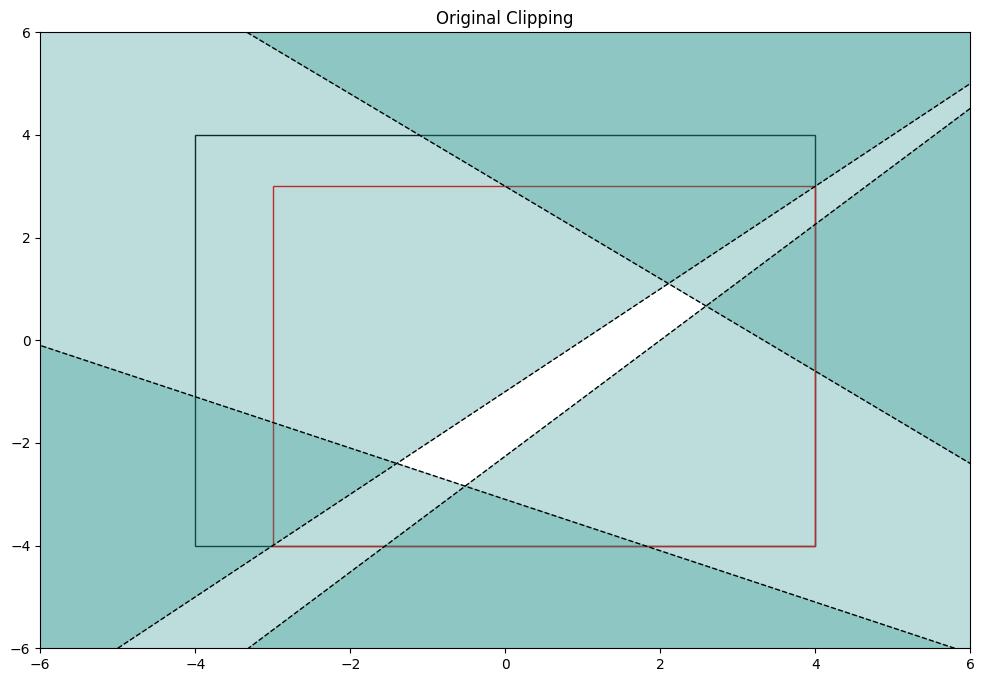

In [273]:
batches = 1
input_dim = 2
spec_dim = 4
config = OrderedDict({
    'x_L': -4 * torch.ones((batches, input_dim), **set_t),
    'x_U': 4 * torch.ones((batches, input_dim), **set_t),
    'lA': torch.tensor([
          [3.5, -3.1],
          [0.9, 1.],
          [-5, -10],
          [-1, 1],
        ], **set_t).reshape(batches, spec_dim, input_dim),
    'lbias': torch.tensor([-9, -5, -33, -1], **set_t).reshape(batches, spec_dim),
    'thresholds': -2*torch.ones((batches, spec_dim), **set_t).reshape(batches, spec_dim),
})
new_x_L_one, new_x_U_one, _, _ = clip_domains(
    config['x_L'],
    config['x_U'],
    config['thresholds'],
    config['lA'],
    None,
    lbias=config['lbias'],
    calculate_dm_lb=True,
)
print(f"new_x_L_one: \n{to_numpy(new_x_L_one)}")
print(f"new_x_U_one: \n{to_numpy(new_x_U_one)}")

plot_2d_domain(config['x_L'], config['x_U'], config['lA'], config['lbias'],
                config['thresholds'],
                   new_x_L_one,
                   new_x_U_one,
                  plot_args={'plot_intersection': False,
                             'figsize': (12, 8),
                             'subplot_max_width': 3,
                             'show_grid': False,
                             'show_ticks': True,
                             'show_legend': False,
                             'show_labels': False,
                              'global_x_L': np.array([-6, -6]),
                              'global_x_U': np.array([6, 6]),
                              'subplot_titles': ['Original Clipping']
                              })

Below, we create two convex polytope objects as neural network objects and form a multi convex polytope object which will later be used to check for intersection. In this code block as well, we plot an example of two convex polytopes that slightly intersect each other. They are defined by the same half-spaces, but one is translated.

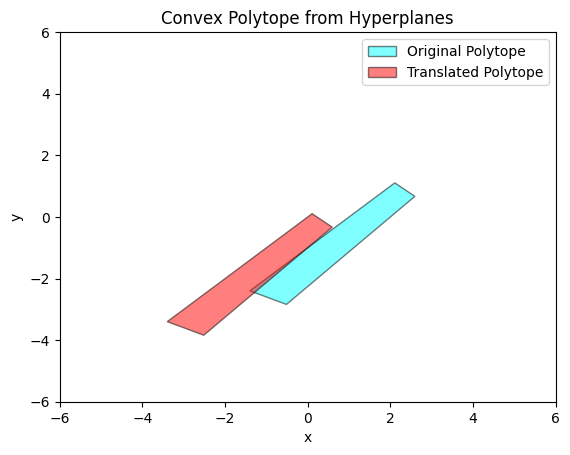

In [274]:
# initialize the original convex polytope and one that is translated slightly
translation = -1 * torch.tensor([-2, -1], **set_t)
translation_np = to_numpy(translation)
convex_A = config['lA'][0]
convex_b = config['lbias'][0] - config['thresholds'][0]
net_original = ConvexPolytope(convex_A, convex_b, use_sum_layer=False, translation=None, normalize=True).to(**set_t)
net_translated = ConvexPolytope(convex_A, convex_b, use_sum_layer=False, translation=translation, normalize=True).to(**set_t)
# this object combines the two polytopes
multi_net = MultiConvexPolytopes((net_original, net_translated))

_, ax = plt.subplots(1, 1)
ax.set_xlim((-6, 6))
ax.set_ylim((-6, 6))

# plot the polytopes onto the figure
plot_convex_polytope(ax, to_numpy(convex_A), to_numpy(convex_b), translation=None,
                     label='Original Polytope')
plot_convex_polytope(ax, to_numpy(convex_A), to_numpy(convex_b), translation=translation_np, color='red',
                     label='Translated Polytope')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Convex Polytope from Hyperplanes")
ax.legend()
plt.show()

In [275]:
def calculate_grid_size_mb(grid_size: Union[int, ndarray, Tensor], n_dim: int, el_bytes: int = 4) -> int:
    """
    Returns the number of megabytes that will be used if 'generate_grids' is called.
    :param grid_size:   The number of elements along each dimension in the grid
    :param n_dim:       The dimension of the grid
    :param el_bytes:    The number of bytes per element in the grid
    :return:            The number of megabytes of the entire grid
    """
    if isinstance(grid_size, (ndarray, Tensor)):
        assert len(grid_size.shape) == 1, "Expected a 1D array or tensor"

    grid_sizes = [grid_size] * n_dim if isinstance(grid_size, int) else grid_size
    cartesian_elements = 1
    for n in range(n_dim):
        cartesian_elements *= grid_sizes[n]

    num_elements = cartesian_elements * n_dim
    num_bytes = num_elements * el_bytes
    num_mb = num_bytes // (1024**2)

    return num_mb


def generate_grids(lower_limit, upper_limit, grid_size):
    ndim = lower_limit.size(0)
    assert ndim == upper_limit.size(0)
    assert lower_limit.ndim == upper_limit.ndim == 1
    grids = [None] * ndim
    steps = (upper_limit - lower_limit) / grid_size
    for d in range(ndim):
        grids[d] = torch.linspace(
            lower_limit[d], upper_limit[d], int(grid_size[d].item() + 1), device=lower_limit.device
        )[: int(grid_size[d].item())]
    lower = torch.cartesian_prod(*grids)
    upper = lower + steps
    lower = lower.to(device=lower_limit.device)
    upper = upper.to(device=lower_limit.device)
    return lower, upper

def generate_grids_on_box_boundary(
    lower_boundary: Tensor, upper_boundary: Tensor, grid_size: Tensor
) -> Tuple[Tensor, Tensor]:
    """
    Generate grids on the box boundary.

    Return: (lower, upper) The i'th row is the lower and upper bound of the
    i'th grid cell.
    """
    x_dim = lower_boundary.numel()
    lower = torch.empty((0, x_dim)).to(lower_boundary)
    upper = torch.empty((0, x_dim)).to(lower_boundary)
    # Loop through each face
    for i in range(x_dim):
        grid_size_i = grid_size.clone()
        grid_size_i[i] = 1
        # First generate grid on the i'th coordinate lower plane.
        upper_boundary_i = upper_boundary.clone()
        upper_boundary_i[i] = lower_boundary[i]
        lower_i, upper_i = generate_grids(lower_boundary, upper_boundary_i, grid_size_i)
        lower = torch.cat((lower, lower_i), dim=0)
        upper = torch.cat((upper, upper_i), dim=0)
        # Now generate grid on the i'th coordinate upper plane
        lower_boundary_i = lower_boundary.clone()
        lower_boundary_i[i] = upper_boundary[i]
        lower_i, upper_i = generate_grids(lower_boundary_i, upper_boundary, grid_size_i)
        lower = torch.cat((lower, lower_i), dim=0)
        upper = torch.cat((upper, upper_i), dim=0)
    return lower, upper

def get_lower_bounds(bounded_net: BoundedModule, xl: Tensor, xu: Tensor):
    needed_A_dict = defaultdict(set)
    output_name = bounded_net.output_name[0]
    input_name = bounded_net.input_name[0]
    needed_A_dict[output_name].add(input_name)
    ptb = PerturbationLpNorm(x_L=xl, x_U=xu)
    bounded_x = BoundedTensor((xu + xl)/2, ptb).to(xl)
    result = bounded_net.compute_bounds(x=(bounded_x,), method='crown', needed_A_dict=needed_A_dict,
                                        bound_lower=True, bound_upper=True,
                                        return_A=True)  # dynamic forward
    may_lower, may_upper, A_dict = result
    lA = A_dict[output_name][input_name]['lA']
    lbias = A_dict[output_name][input_name]['lbias']
    uA = A_dict[output_name][input_name]['uA']
    ubias = A_dict[output_name][input_name]['ubias']
    return may_lower, may_upper, lA, lbias, uA, ubias

In [276]:
# bound the multi_net object and take a look at its lower bounds
bounded_net = BoundedModule(multi_net, torch.empty((1, 2)))
may_lower, may_upper, lA, lbias, uA, ubias = get_lower_bounds(bounded_net, config['x_L'], config['x_U'])
is_safe = (may_lower > 0).any(1)
print(f"is_safe: {to_numpy(is_safe)}")
print(f"may_lower (shape: {may_lower.shape}): \n{to_numpy(may_lower)}")

is_safe: [False]
may_lower (shape: torch.Size([1, 8])): 
[[ 0.         0.         0.        -4.9497476  0.         0.
   0.         0.       ]]


In [277]:
# take the original input domain and split it w.r.t. to our desired grid size
xl, xu = config['x_L'].squeeze(0), config['x_U'].squeeze(0)
print(f"xl: {xl}, xu: {xu}")
xl, xu = generate_grids(xl, xu, grid_size=torch.tensor([3, 3], **set_t))
print(f"new xl: {xl.shape}, new xu: {xu.shape}")

xl: tensor([-4., -4.], device='cuda:0'), xu: tensor([4., 4.], device='cuda:0')
new xl: torch.Size([9, 2]), new xu: torch.Size([9, 2])


In [278]:
# bound each grid and take a look at which subdomains were verified safe (no intersection)
start_time = time()
may_lower, may_upper, lA, lbias, uA, ubias = get_lower_bounds(bounded_net, xl, xu)
is_safe = to_numpy((may_lower > 0).any(1))
not_safe = np.logical_not(is_safe)
end_time = time()
time_taken = end_time - start_time
print(f"time_taken: {time_taken}")
# print(f"may_lower: \n{to_numpy(may_lower)}")
print(f"is_safe: {is_safe}")
print(f"lA shape: {lA.shape}, lbias shape: {lbias.shape}")

time_taken: 0.00662541389465332
is_safe: [False  True  True False False  True  True False  True]
lA shape: torch.Size([9, 8, 2]), lbias shape: torch.Size([9, 8])


Now that we have bounded our subdomains, we perform clipping on all of them. However, we do not plot the subdomains that were verified as safe, as we are now only concerned about the subdomains for which we could not verify. Either we split these domains further in attempt to verify them, or we search for a counter example using pgd attacks.

We demonstrate the results of pgd attacks with and without clipping. Notice how with clipping, it is much easier to find many more counter examples of intersection as the subdomains are shrunken to remove the regions that are safe.

Domain clipping: already verified 5, shrunken 4 
Found 3 adversarial examples.
Found 25 adversarial examples.


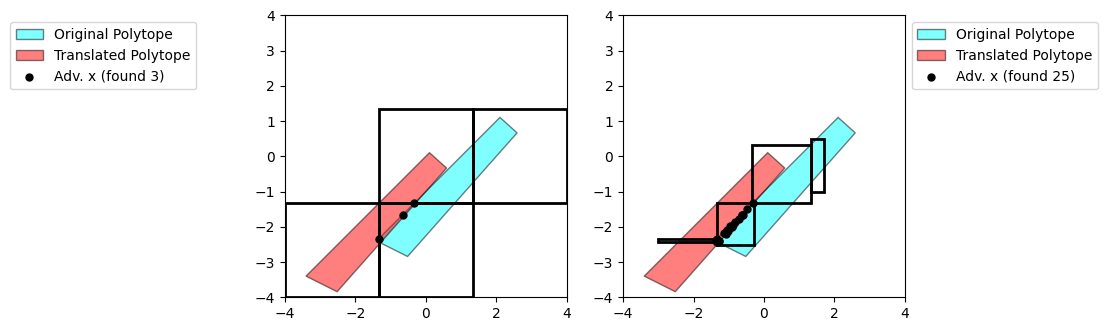

In [279]:
new_xl, new_xu, _, _ = clip_domains(
    xl,
    xu,
    torch.zeros_like(lbias),
    lA,
    None,
    lbias=lbias,
    calculate_dm_lb=True,
)

_, axes = plt.subplots(1, 2, figsize=(8, 10))
for ax in axes:
    # plot the polytopes onto the figure
    plot_convex_polytope(ax, to_numpy(convex_A), to_numpy(convex_b), translation=None,
                         label='Original Polytope')
    plot_convex_polytope(ax, to_numpy(convex_A), to_numpy(convex_b), translation=translation_np, color='red',
                         label='Translated Polytope')

original_boxes = to_numpy(torch.cat((xl, xu), dim=1))
new_boxes = to_numpy(torch.cat((new_xl, new_xu), dim=1))
pgd_samples = 50
std_dev = 0.1  # Standard deviation of the noise
pgd_steps = 5
for curr_boxes, ax in zip((original_boxes, new_boxes), axes):
    all_adv_x_np = []
    for box, s in zip(curr_boxes, is_safe):
        # We loop through every subdomain that was not verified safe and display its box after clipping as well as
        # attempt to adversarial examples via pgd attacks.
        if s:
            continue

        # put the clipped subdomain in the plot
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        ax.add_patch(patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='black', facecolor='none'))

        # Perform pgd attacks to find points where every polytope intersects each other.
        # Initialize x from a uniform distribution on the subdomain
        x = torch.rand((pgd_samples, 2), **set_t) * torch.tensor([x2 - x1, y2 - y1], **set_t).reshape(1, -1) + torch.tensor([x1, y1], **set_t).reshape(1, -1)
        x = x.requires_grad_(True)
        # Get the limits of the box for clipping the input
        curr_xl = torch.tensor([x1, y1], **set_t)
        curr_xu = torch.tensor([x2, y2], **set_t)
        # Record the best losses and their corresponding inputs
        best_loss = torch.full((pgd_samples,), torch.inf, **set_t)
        best_x = x.detach().clone()
        opt = Adam([x], maximize=False)
        for i in range(pgd_steps):
            opt.zero_grad()
            y = multi_net(x)
            loss = y.sum(1)
            with torch.no_grad():
                # record the best losses and inputs
                best_mask = loss < best_loss
                best_loss[best_mask] = loss[best_mask]
                best_x[best_mask] = x[best_mask].detach().clone()
            if i == pgd_steps - 1:
                # finished optimization
                break
            loss = loss.mean()
            loss.backward()
            opt.step()
            with torch.no_grad():
                # Add a small perturbation to the new input so that it does not get stuck at local minima.
                # This helps with finding more counter examples.
                noise = torch.randn_like(x) * std_dev  # Generate noise from N(0, std_dev^2)
                # clip the input
                x = torch.clip(x + noise, min=curr_xl, max=curr_xu)

        # extract and append the adversarial examples
        adv_x = best_x[best_loss <= 0]
        adv_x_np = to_numpy(adv_x)
        if len(adv_x_np) > 0:
            all_adv_x_np.append(adv_x_np)

    if len(all_adv_x_np) > 0:
        # if adversarial examples were found, display them in the plot
        all_adv_x_np = np.concatenate(all_adv_x_np, axis=0)
        num_adv_x = len(all_adv_x_np)
        print(f"Found {num_adv_x} adversarial examples.")
        ax.scatter(all_adv_x_np[:, 0], all_adv_x_np[:, 1], color='black', label=f'Adv. x (found {num_adv_x})', s=25)

# Set the axis limits based on the box coordinates
for i, ax in enumerate(axes):
    ax.set_xlim(config['x_L'][0, 0].item(), config['x_U'][0, 0].item())
    ax.set_ylim(config['x_L'][0, 1].item(), config['x_U'][0, 1].item())
    ax.set_aspect('equal', 'box')
    bbox_to_anchor = (-1, 1) if i == 0 else (1, 1)
    ax.legend(loc='upper left', bbox_to_anchor=bbox_to_anchor)

# Show the plot
plt.show()